# Fig2B: Compare the longitudinal intra donor variability of ARI and con2
- related to Fig 2B
- compare the variability of healthy control CON2 and ARI longitudinally
- calculate the CV for ALTRA converters and BRI healthy
- compared the CV

In [1]:
# load library
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("data.table")
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("Matrix")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("future")
quiet_library("future.apply")
quiet_library("PALMO")
quiet_library("scran")
quiet_library("SingleCellExperiment")
quiet_library("DESeq2")
quiet_library("ggpubr")
quiet_library("parallel")

In [2]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
options(repr.plot.width = 20, repr.plot.height = 15)

In [3]:
# define file path
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/output_results_oldIDE/output_results/integration"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/integration"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"

if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "ALTRA_AIM3_BRI_scRNA_PALMO_"

In [4]:
#' DEseq2Norm
#'
#' This function performs DESeq2 normalization on a given SummarizedExperiment object.
#'
#' @param pb_se A SummarizedExperiment object containing the raw counts to be normalized.
#'
#' @return A SummarizedExperiment object with an added assay containing the variance stabilized transformed counts.
#'
#' @details
#' The function first creates a DESeqDataSet object with a design formula of `~ 1`, indicating no specific design.
#' It then applies the variance stabilizing transformation (VST) to the DESeqDataSet object.
#' The resulting VST counts are added as a new assay to the input SummarizedExperiment object.
#'
#' @import DESeq2
#' @import SummarizedExperiment
#'
#' @examples
#' \dontrun{
#' library(DESeq2)
#' library(SummarizedExperiment)
#' 
#' # Example usage
#' pb_se <- SummarizedExperiment(assays = list(counts = matrix(rpois(100, lambda = 10), ncol = 10)))
#' pb_se <- DEseq2Norm(pb_se)
#' }

DEseq2Norm <- function(pb_se) {
    # get deseq2 normalized counts
    # run deseq to get normalized counts
    pb_des <- DESeqDataSet(pb_se, design = as.formula("~ 1"))
    vsd <- varianceStabilizingTransformation(pb_des, blind = TRUE)
    assay(pb_se, "vst") <- assay(vsd)
    return(pb_se)
}

#' Compare_CV
#'
#' This function performs a cross-validation (CV) comparison for a specified cell type using provided pseudobulk data.
#'
#' @param celltype_test A character string specifying the cell type to test.
#' @param pb_data A SummarizedExperiment object containing pseudobulk data.
#' @param n_cores An integer specifying the number of cores to use for parallel processing. Default is 1.
#'
#' @return A tibble containing combined CV distributions for the specified cell type, with status annotations.
#'
#' @details
#' The function filters the input data based on the specified cell type and performs several preprocessing steps,
#' including filtering low-expressed genes and normalizing the data using DESeq2. It then creates PALMO data objects
#' for both converters and healthy samples, annotates metadata, merges data, and calculates CV distributions.
#' Finally, it combines the CV distributions for converters and healthy samples and returns the result as a tibble.
#'
#' @examples
#' \dontrun{
#' # Example usage:
#' result <- Compare_CV(celltype_test = "T_cells", pb_data = pseudobulk_data, n_cores = 4)
#' }
#'
#' @import SummarizedExperiment
#' @import SingleCellExperiment
#' @import DESeq2
#' @import dplyr
#' @import PALMO
#' @import tibble
#' @importFrom magrittr %>%
#' @importFrom stats na.omit
#' @importFrom scales scale
#' @export

Compare_CV <- function(celltype_test, pb_data, n_cores = 1) {
    message(paste("processing", celltype_test))
    # filter on cell type
    pb_se <- pb_data[, colData(pb_se_lg)$cell_type == celltype_test]
    # # do some general filter to low expressed genes
    smallestGroupSize <- 30
    keep <- rowSums(assay(pb_se, "counts") >= 10) >= smallestGroupSize
    pb_se <- pb_se[keep, ]
    # run deseq2 and batch normalizatoin
    pb_se <- DEseq2Norm(pb_se)
    message(paste("processing", as.character(nrow(pb_se)), "genes"))
    pb_sce <- as(pb_se, "SingleCellExperiment")
    # subset the longitudinal ALTRA model
    pb_ra <- pb_sce[, (!is.na(colData(pb_sce)$days_to_conversion)) &
        (colData(pb_sce)$days_to_conversion > -750)]

    # create a palmo data object
    colnames(pb_ra) <- colData(pb_ra)$sample.sampleKitGuid
    expression <- assay(pb_ra, "vst")
    metadata <- colData(pb_ra) %>%
        as.data.frame() %>%
        mutate(
            Sample = sample.sampleKitGuid,
            days_to_conversion_scale = scale(days_to_conversion)
        )
    palmo_ra <- createPALMOobject(anndata = metadata, data = expression)

    palmo_ra <- annotateMetadata(
        data_object = palmo_ra,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_to_conversion"
    )
    # Sample overlap and final matrix
    palmo_ra <- mergePALMOdata(data_object = palmo_ra, datatype = "bulk")
    # CV distribution
    cv_ra <- cvCalcBulkProfile(data_object = palmo_ra, cl = n_cores)

    # subset the longitudinal ALTRA model
    pb_bri <- pb_sce[, colData(pb_sce)$status == "BRI_healthy"]

    # create a palmo data object
    colnames(pb_bri) <- colData(pb_bri)$sample.sampleKitGuid
    expression <- assay(pb_bri, "vst")
    metadata <- colData(pb_bri) %>%
        as.data.frame() %>%
        mutate(Sample = sample.sampleKitGuid)
    palmo_bri <- createPALMOobject(anndata = metadata, data = expression)

    palmo_bri <- annotateMetadata(
        data_object = palmo_bri,
        sample_column = "Sample",
        donor_column = "subject.subjectGuid",
        time_column = "days_since_last"
    )
    # Sample overlap and final matrix
    palmo_bri <- mergePALMOdata(data_object = palmo_bri, datatype = "bulk")
    # CV distribution
    cv_bri <- suppressMessages(cvCalcBulkProfile(data_object = palmo_bri, cl = n_cores))
    # combine CV
    cv_comb <- as_tibble(cv_ra) %>%
        mutate(status = "converters") %>%
        bind_rows(as_tibble(cv_bri) %>% mutate(status = "bri_healthy")) %>%
        mutate(cell_type = celltype_test)
    return(cv_comb)
}

# load pseudobulk data for all AIMs
- inclduding BRI longitudinal

In [35]:
# load pseudobulk data for all samples
pb_se_all <- readRDS("/home/workspace/data/ALTRA_manuscript/ALTRA_BRI_combined_AIFI_L2_pseudobulk_object.rds")

In [36]:
# add status column
pb_se_all$status <- replace_na(pb_se_all$status, "BRI_healthy")

In [37]:
# check sample number
colData(pb_se_all) %>%
  as_tibble() %>%
  distinct(sample.sampleKitGuid,
    .keep_all = TRUE
  ) %>%
  group_by(status) %>%
  tally()

status,n
<chr>,<int>
ALTRA_healthy,31
BRI_healthy,89
at_risk,31
conversion,11
early_RA,13
pre-conversion,55


In [38]:
# filter days to conversion to less than -750 days
pb_se_lg <- pb_se_all[, is.na(pb_se_all$days_to_conversion) | pb_se_all$days_to_conversion > (-750)]

In [39]:
pb_se_lg

class: SummarizedExperiment 
dim: 28879 5321 
metadata(0):
assays(1): counts
rownames(28879): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(5321): KT00070_ASDC KT03931_ASDC ... KT02536_pDC KT02540_pDC
colData names(52): index batch_id ... cell_type bmi_conv_cat

In [40]:
colData(pb_se_lg) %>%
  as_tibble() %>%
  distinct(sample.sampleKitGuid,
    .keep_all = TRUE
  ) %>%
  group_by(status) %>%
  tally()

status,n
<chr>,<int>
ALTRA_healthy,31
BRI_healthy,89
at_risk,31
conversion,11
early_RA,13
pre-conversion,49


# use PLAMO to calculate CV in longitudinal samples

In [41]:
pb_sce <- as(pb_se_lg, "SingleCellExperiment")

In [42]:
colnames(pb_sce) <- paste(colnames(pb_sce), pb_sce$cell_type, sep = "_")

# loop for all cell types

In [54]:
pb_sce

class: SingleCellExperiment 
dim: 28879 5321 
metadata(0):
assays(1): counts
rownames(28879): A1BG A1BG-AS1 ... ZYX ZZEF1
rowData names(0):
colnames(5321): KT00070_ASDC_ASDC KT03931_ASDC_ASDC ... KT02536_pDC_pDC
  KT02540_pDC_pDC
colData names(52): index batch_id ... cell_type bmi_conv_cat
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

### remvove cell type where sample numbers were too low

In [55]:
# calculate sample number in different cell type
celltype_counts <- colData(pb_se_lg) %>%
  as_tibble() %>%
  group_by(cell_type, cohort) %>%
  tally()
celltype_counts %>% head()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6
CD14 monocyte,ALTRA,135
CD14 monocyte,BRI,89
CD16 monocyte,ALTRA,135
CD16 monocyte,BRI,89


In [74]:
rare_celltypes <- celltype_counts %>% filter(n < 15)
rare_celltypes
l2_celltypes <- pb_se_all$cell_type %>% unique()
l2_celltypes <- l2_celltypes[!l2_celltypes %in% rare_celltypes$cell_type]
l2_celltypes %>% length()

cell_type,cohort,n
<chr>,<chr>,<int>
ASDC,ALTRA,2
ASDC,BRI,6


[1] 28

### remove cell type where the total cell number were too low

In [60]:
# calculate the cell counts
pse_cell_counts <- lapply(l2_celltypes, function(celltype_test) {
  pb_se <- pb_se_lg[, colData(pb_se_lg)$cell_type == celltype_test]
  smallestGroupSize <- 30
  keep <- rowSums(assay(pb_se, "counts") >= 10) >= smallestGroupSize
  pb_se <- pb_se[keep, ]
  cell_count <- colData(pb_se) %>%
    as.data.frame() %>%
    select(sample.sampleKitGuid, subject.subjectGuid, psbulk_n_cells, status) %>%
    mutate(cell_type = celltype_test)
  return(cell_count)
}) %>% rbindlist()

In [71]:
avg_cellcounts <- pse_cell_counts %>%
  filter(status %in% c("ALTRA_healthy", "at_risk", "conversion")) %>%
  group_by(cell_type, status) %>%
  summarise(mean_cellcount = mean(psbulk_n_cells)) %>%
  arrange(mean_cellcount)
avg_cellcounts %>%
  filter(mean_cellcount < 15)

`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,status,mean_cellcount
<chr>,<chr>,<dbl>
cDC1,ALTRA_healthy,10.71429
cDC1,at_risk,12.11111
ILC,conversion,12.33333
ILC,at_risk,12.66667
ILC,ALTRA_healthy,13.00000


In [75]:
# remove ILC and cDC1 from the analysis due to low cell numbers
l2_celltypes <- l2_celltypes[!l2_celltypes %in% c("cDC1", "ILC")]

### calculate CV

In [76]:
l2_celltypes

[1] "CD14 monocyte"         "CD16 monocyte"         "CD56bright NK cell"   
 [4] "CD56dim NK cell"       "CD8aa"                 "DN T cell"            
 [7] "Effector B cell"       "Erythrocyte"           "Intermediate monocyte"
[10] "MAIT"                  "Memory B cell"         "Memory CD4 T cell"    
[13] "Memory CD8 T cell"     "Naive B cell"          "Naive CD4 T cell"     
[16] "Naive CD8 T cell"      "Plasma cell"           "Platelet"             
[19] "Progenitor cell"       "Proliferating NK cell" "Proliferating T cell" 
[22] "Transitional B cell"   "Treg"                  "cDC2"                 
[25] "gdT"                   "pDC"

processing CD14 monocyte

converting counts to integer mode

processing 13544 genes

Mon Aug  4 14:14:30 2025: The PALMO object is created.

Mon Aug  4 14:14:30 2025: For outout files, the output directory is created.

Mon Aug  4 14:14:30 2025: Performing Coefficient of variance analysis.

Mon Aug  4 14:14:30 2025: Performing CV calculations



  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  


Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.
ℹ The deprecated feature was likely used in the PALMO package.
  Please report the issue at <https://github.com/aifimmunology/PALMO/issues>.”


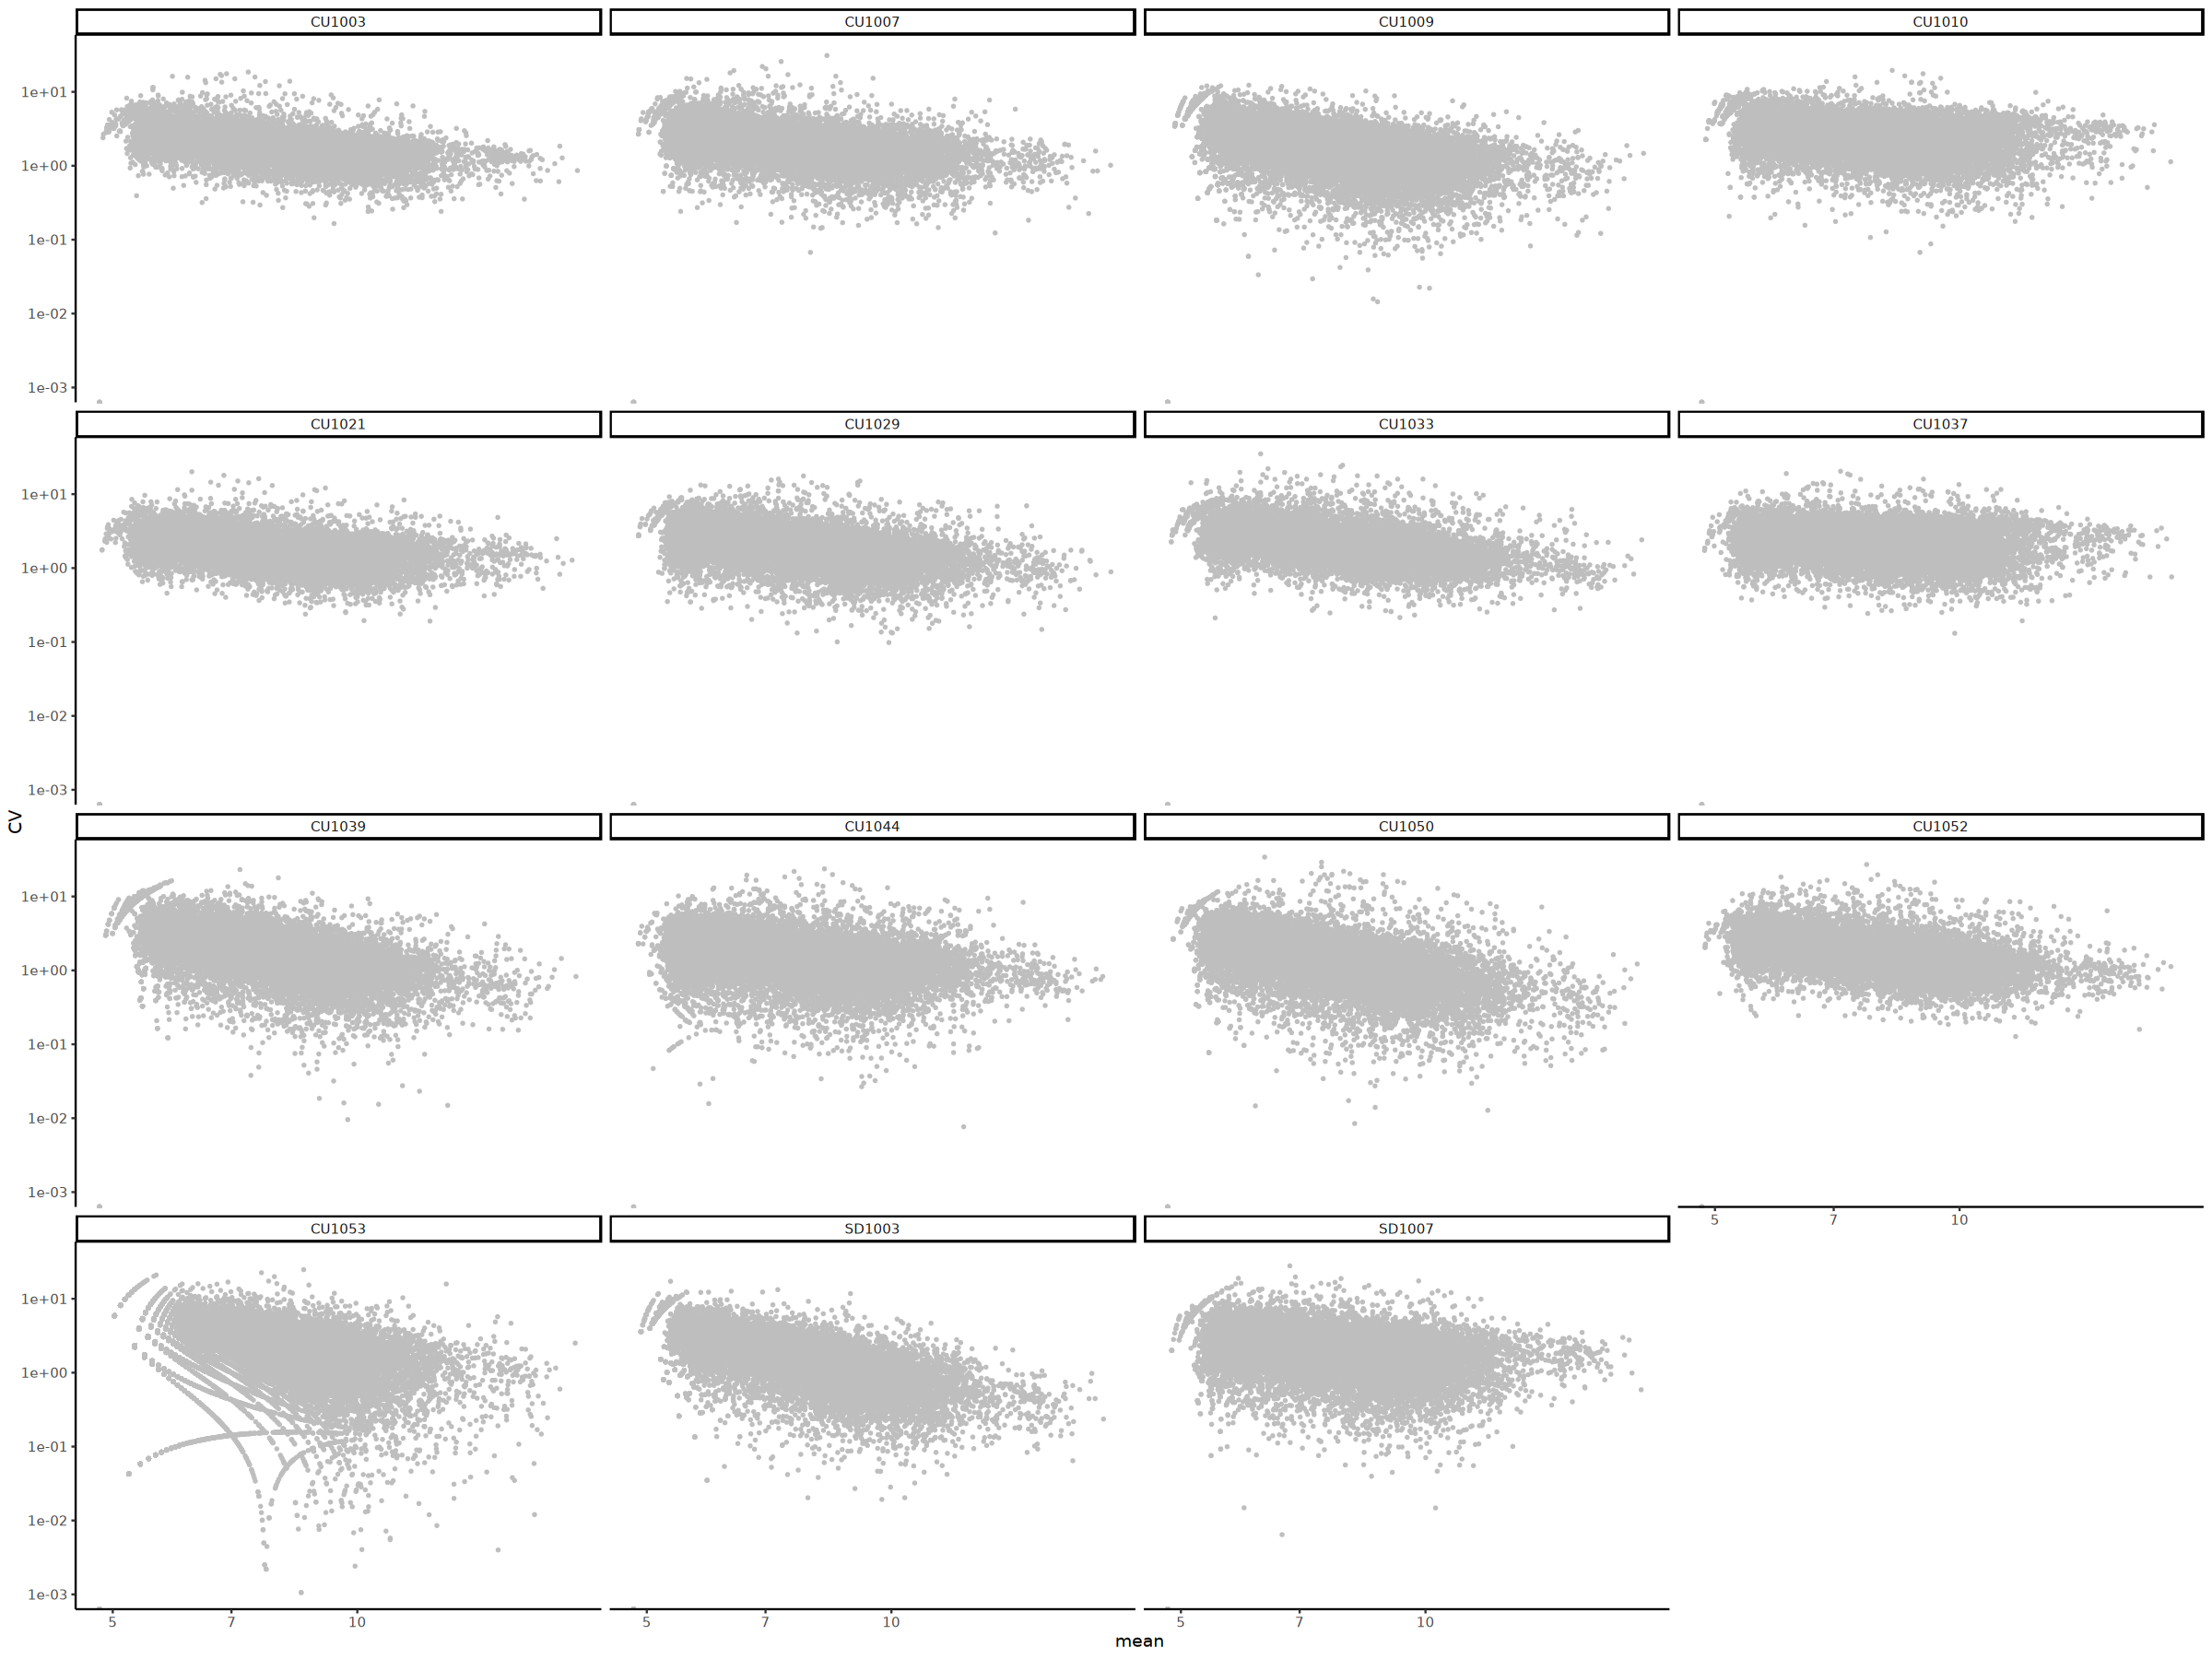

Mon Aug  4 14:14:33 2025: Check out the plots

Mon Aug  4 14:14:38 2025: The PALMO object is created.

Mon Aug  4 14:14:38 2025: For outout files, the output directory is created.



  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=02s  


Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


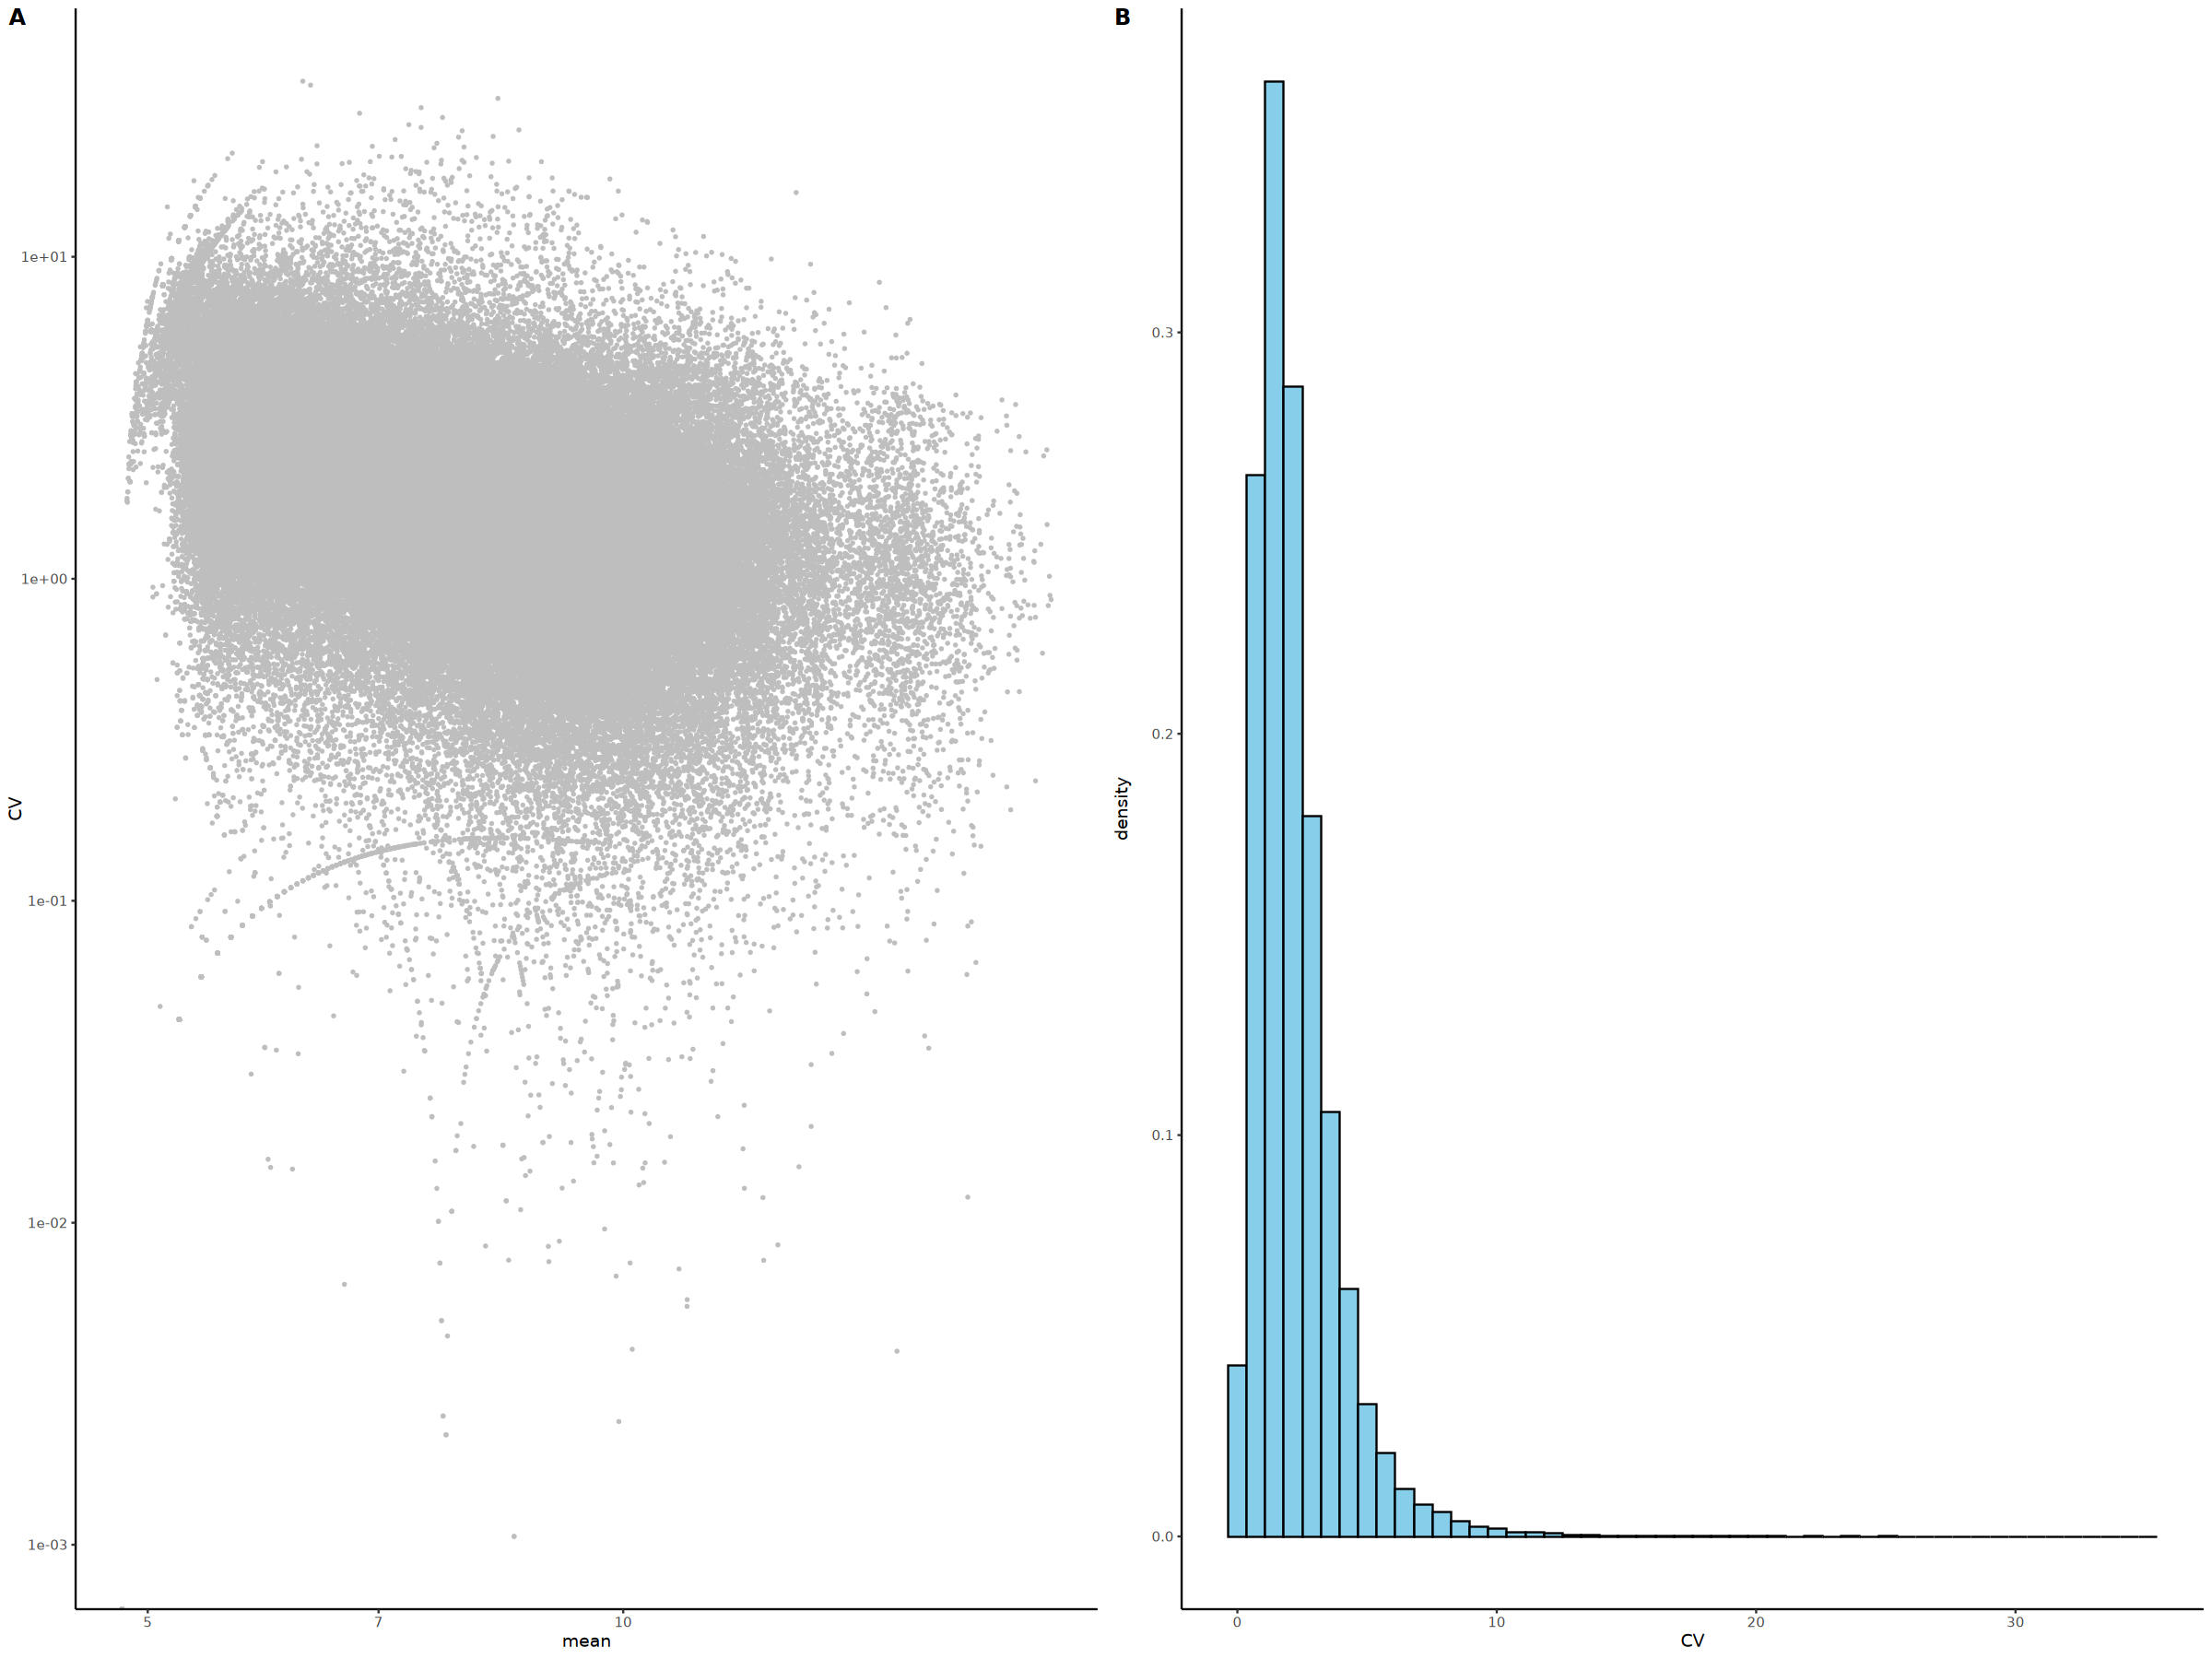

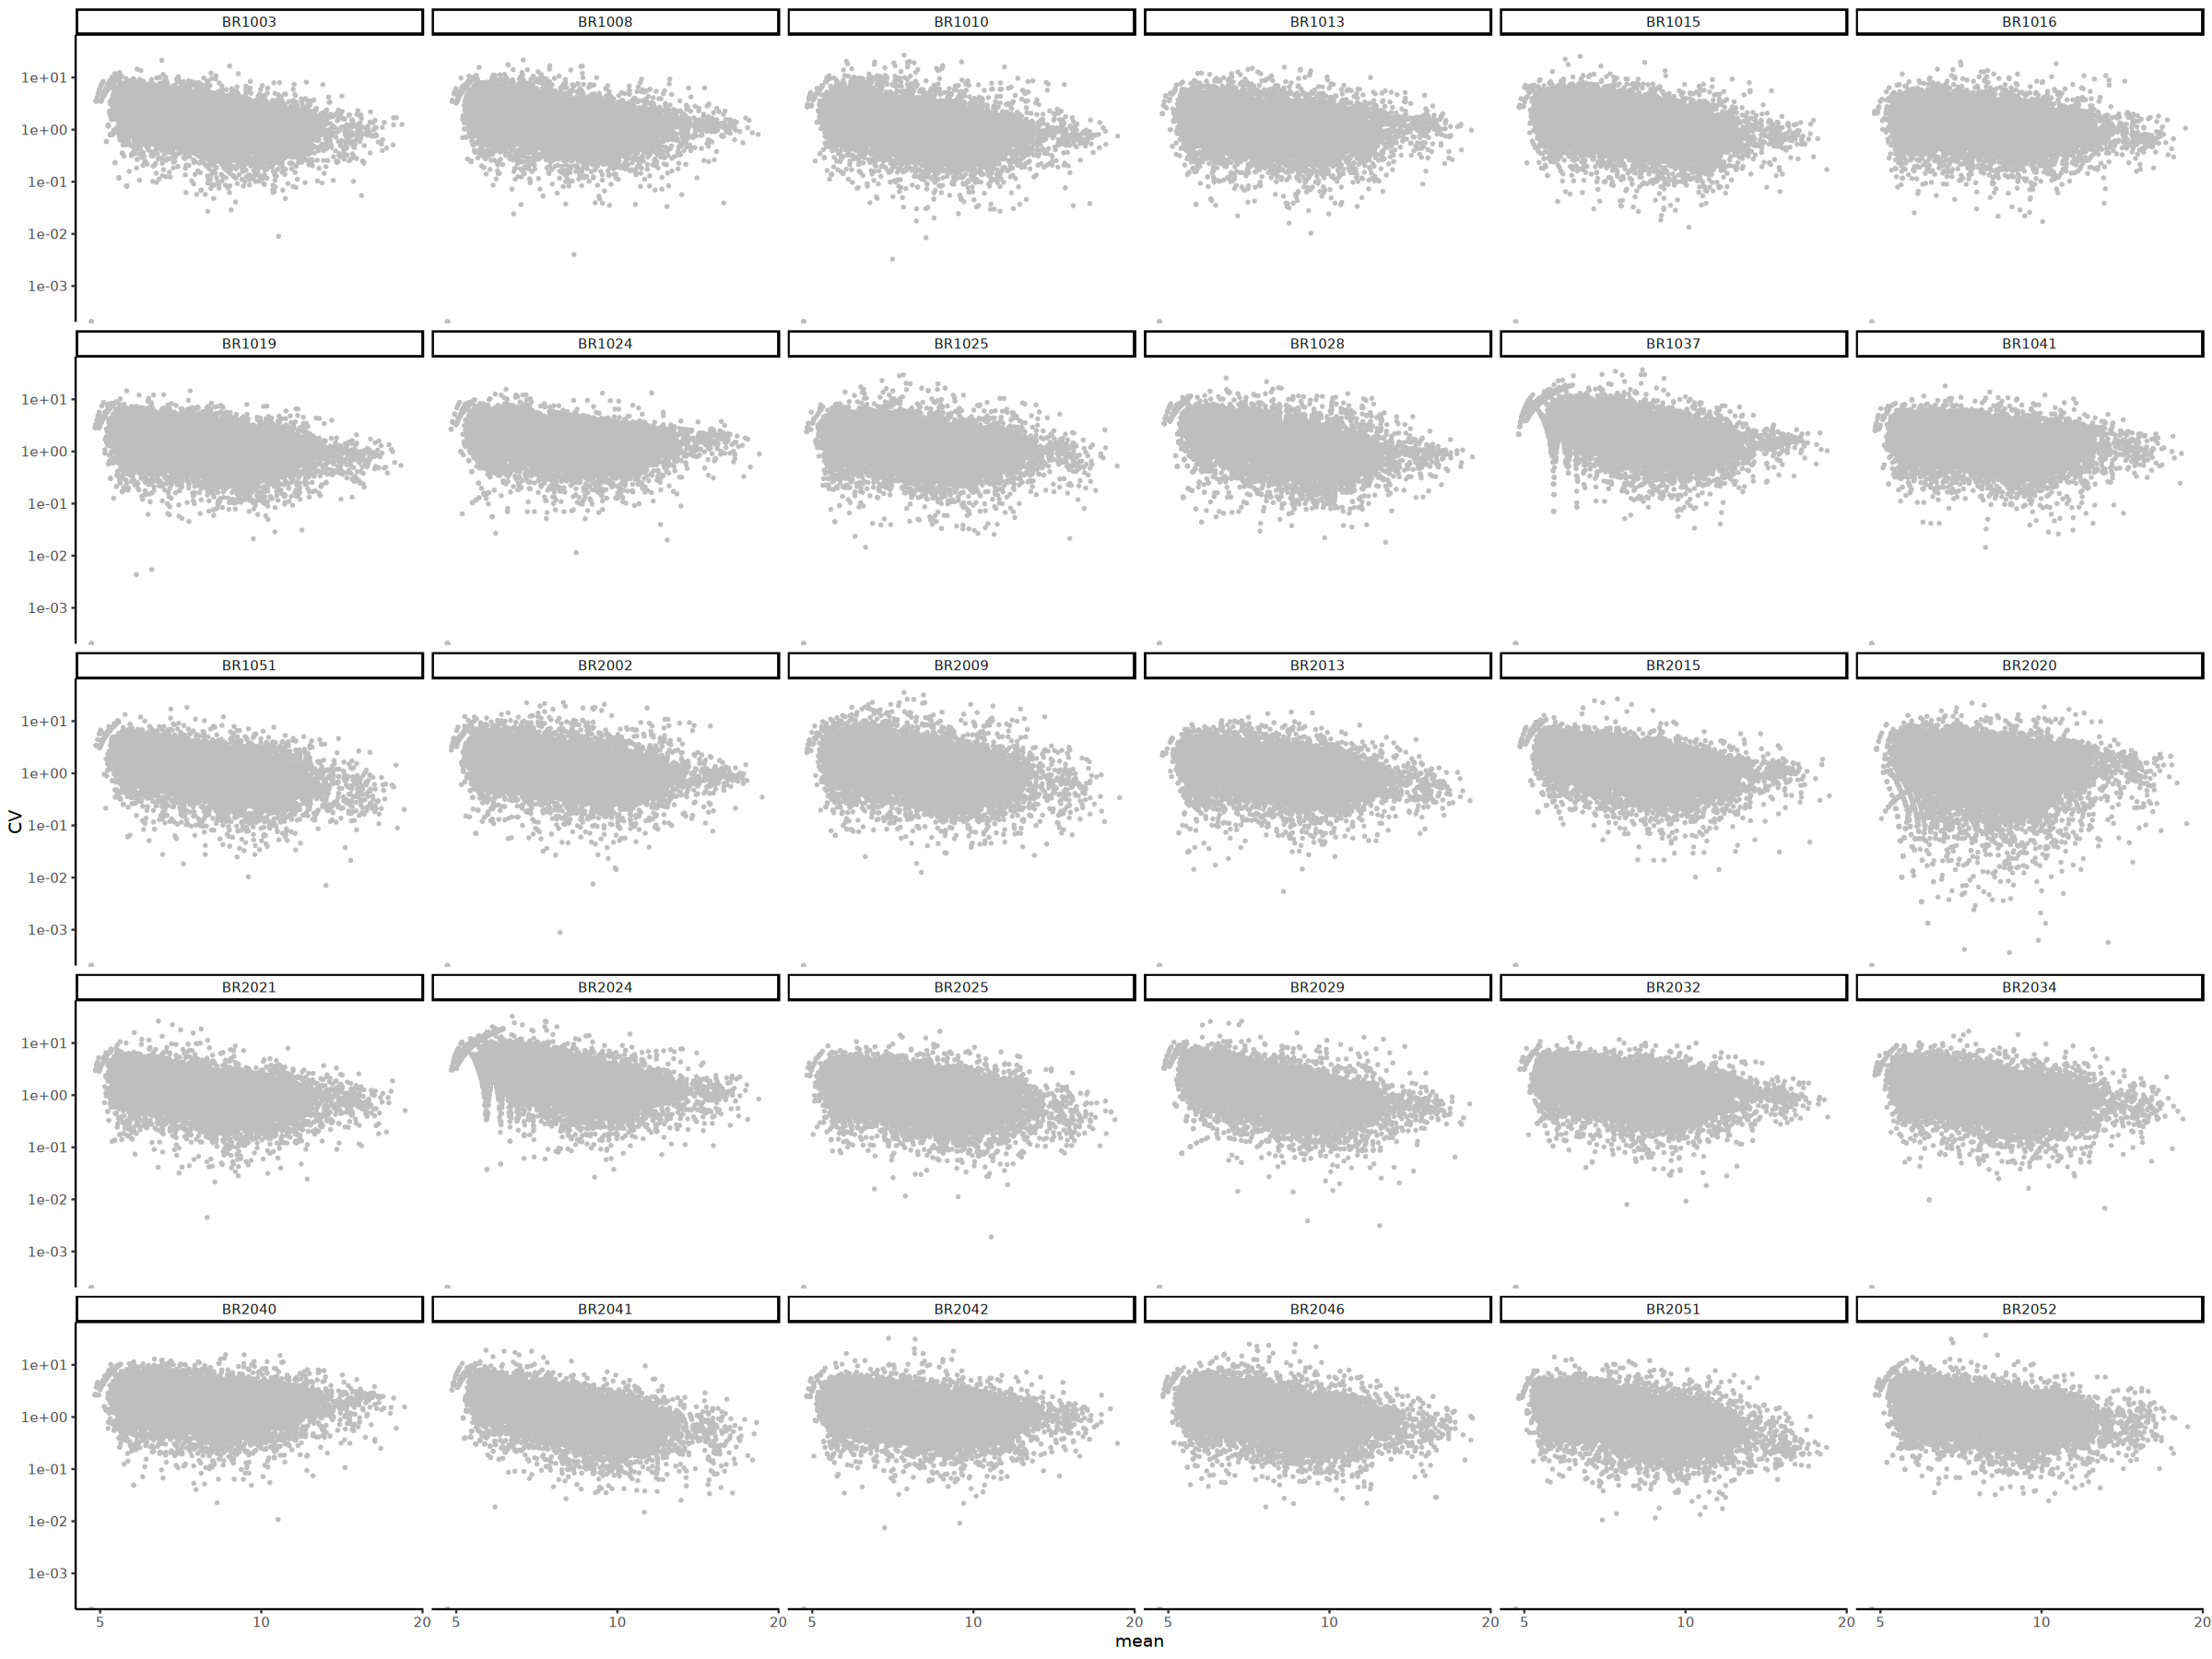

processing CD16 monocyte

converting counts to integer mode

processing 10738 genes

Mon Aug  4 14:15:05 2025: The PALMO object is created.

Mon Aug  4 14:15:05 2025: For outout files, the output directory is created.

Mon Aug  4 14:15:05 2025: Performing Coefficient of variance analysis.

Mon Aug  4 14:15:05 2025: Performing CV calculations



  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  


Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_y_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


In [ ]:
# run CV calculation with PALMO
celltype_cv <- mclapply(l2_celltypes, Compare_CV,
  pb_data = pb_se_lg,
  n_cores = 30, mc.cores = 1
) %>% rbindlist()

In [ ]:
celltype_cv %>% write_tsv(file.path(output_path, "ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype.tsv"))

## analyze the cv results

In [77]:
# load cv data
celltype_cv <- fread(
  "/home/workspace/data/ALTRA_manuscript/ALTRA_AIM3_BRI_scRNA_PALMO_CV_celltype.tsv"
)

In [78]:
# remove BR2024 - this healthy control subject had positive CCP3 therefore remove from all analysis
# remove ILC and cDC1 for low cell numbers
celltype_cv <- celltype_cv %>%
  filter(group != "BR2024") %>%
  filter(!cell_type %in% c("cDC1", "ILC"))

In [79]:
# calculate the ratio of CVs
celltype_cv_ratio <- celltype_cv %>%
  group_by(cell_type, feature, status) %>%
  summarise(mean_cv = mean(CV)) %>%
  arrange(feature) %>%
  pivot_wider(names_from = "status", values_from = "mean_cv") %>%
  filter(!is.na(converters) & !is.na(bri_healthy)) %>%
  mutate(ratio_cv = converters / bri_healthy) %>%
  mutate(direction = factor(if_else(ratio_cv > 1, "Higher CV in ARI to Clincal RA",
    "Higher CV in CON2"
  ), levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA")))

`summarise()` has grouped output by 'cell_type', 'feature'. You can override
using the `.groups` argument.


In [85]:
# output the sup table
table_s14 <- celltype_cv_ratio %>%
  rename(
    "cell_type" = "Cell type", "feature" = "Gene", "bri_healthy" = "mean CV in CON2",
    "converters" = "mean CV in ARI (Converters)",
    "ratio_cv" = "Ratio of CV (Conveters / CON2)"
  )

In [ ]:
table_s14 %>% write_csv(file.path(output_path, "TableS14_ALTRA_CON2_CV_comparison.csv"))

### upload results to HISE

In [1]:
# upload CV calculation results to collab space
hise::uploadFiles(
  files = list("/home/workspace/data/ALTRA_manuscript/TableS14_ALTRA_CON2_CV_comparison.csv"),
  studySpaceId = "223de760-9624-45bd-aefe-ca24c75b1800",
  title = "ALTRA ALTRS CON2 scRNA longitudinal CV comparisons",
  inputFileIds = as.list("97bc72bf-783e-4aaa-998b-149edda0cee0")
)

## plot Fig 2B

In [86]:
# load vc comparison data
table_s14 <- read_csv("/home/workspace/data/ALTRA_manuscript/TableS14_ALTRA_CON2_CV_comparison.csv",
  show_col_types = FALSE
) %>%
  mutate(direction = factor(direction, levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA")))
table_s14 %>% head()

Cell type,Gene,mean CV in CON2,mean CV in ARI (Converters),Ratio of CV (Conveters / CON2),direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
CD14 monocyte,A1BG,1.429729,1.700912,1.1896738,Higher CV in ARI to Clincal RA
CD16 monocyte,A1BG,2.588810,3.105737,1.1996775,Higher CV in ARI to Clincal RA
CD56bright NK cell,A1BG,3.546172,3.007361,0.8480584,Higher CV in CON2
CD56dim NK cell,A1BG,2.318540,2.451917,1.0575262,Higher CV in ARI to Clincal RA
DN T cell,A1BG,4.970682,5.782211,1.1632630,Higher CV in ARI to Clincal RA
Effector B cell,A1BG,3.970334,4.104459,1.0337817,Higher CV in ARI to Clincal RA


In [92]:
# calcualte the counts of genes
cv_direction_counts <- table_s14 %>%
  group_by(`Cell type`, direction) %>%
  tally() %>%
  mutate(
    `Cell type` = factor(`Cell type`, levels = stringr::str_sort(unique(table_s14$`Cell type`))),
    pct = prop.table(n)
  )
cv_direction_counts %>% head()

Cell type,direction,n,pct
<fct>,<fct>,<int>,<dbl>
CD14 monocyte,Higher CV in CON2,1142,0.14912510
CD14 monocyte,Higher CV in ARI to Clincal RA,6516,0.85087490
CD16 monocyte,Higher CV in CON2,723,0.12104470
CD16 monocyte,Higher CV in ARI to Clincal RA,5250,0.87895530
CD56bright NK cell,Higher CV in CON2,264,0.07179766
CD56bright NK cell,Higher CV in ARI to Clincal RA,3413,0.92820234


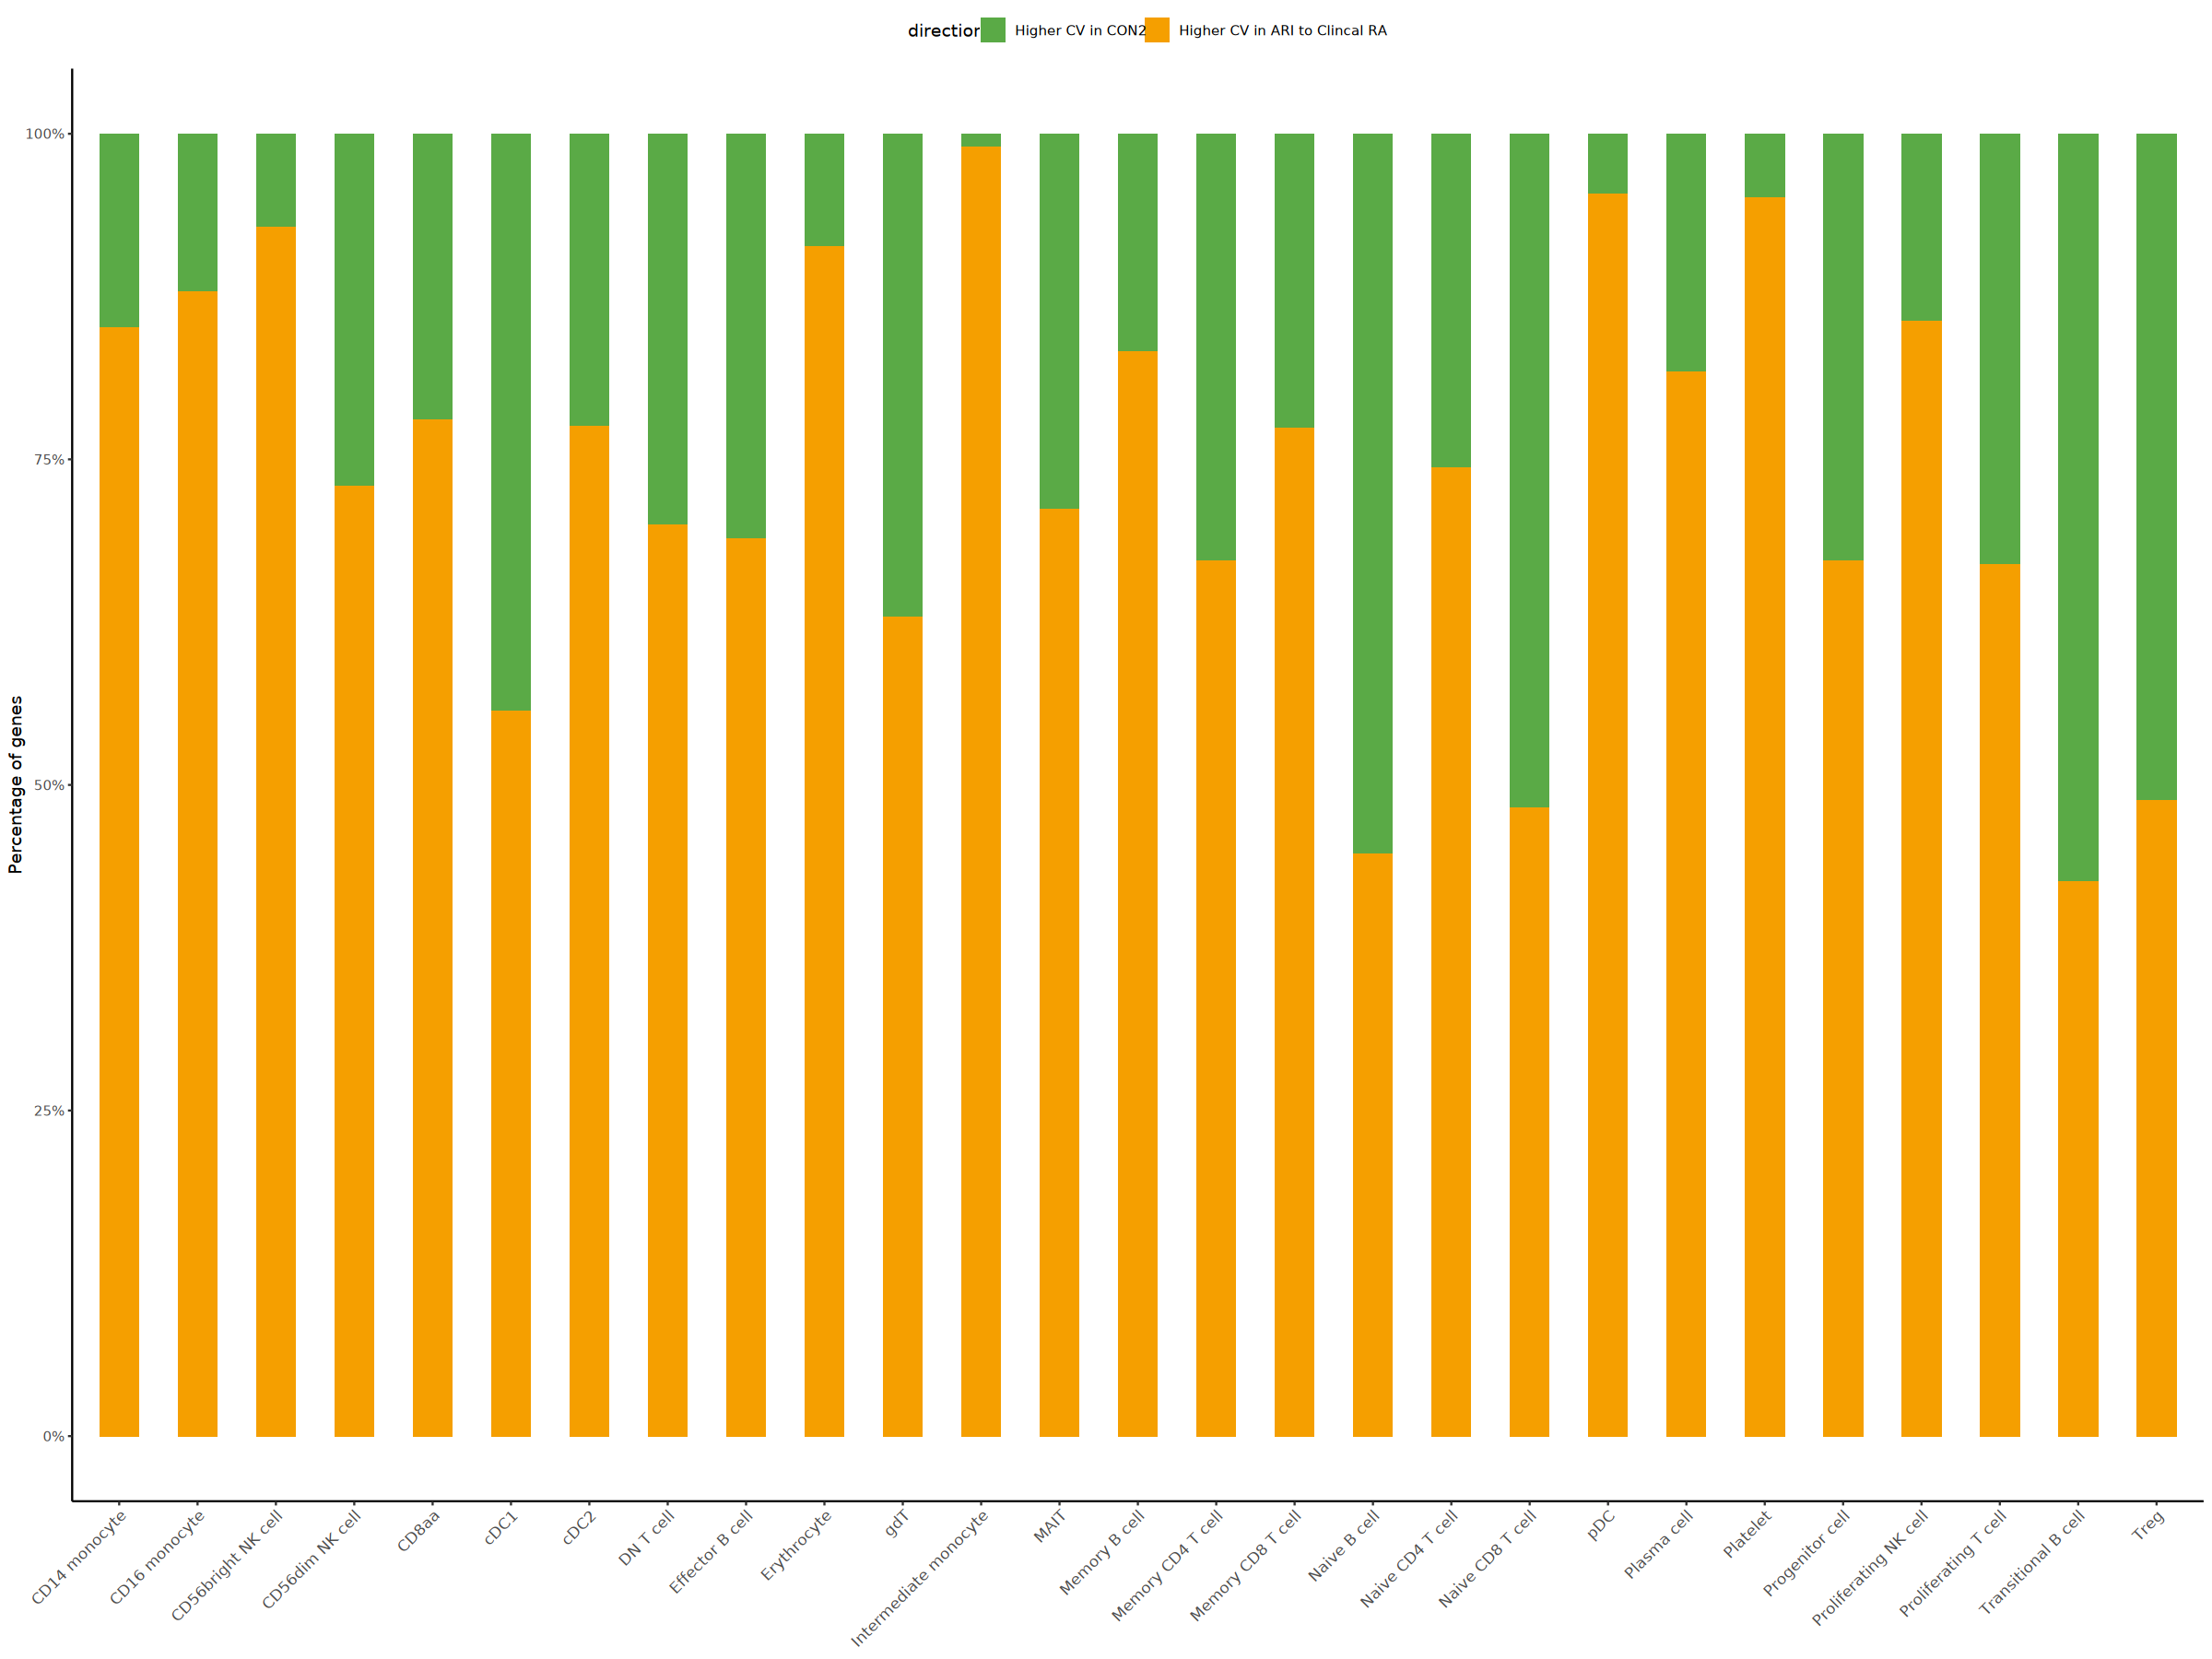

In [93]:
# plot the deg counts
p1 <- ggplot(
  cv_direction_counts,
  aes(width = 0.5, fill = direction, y = pct, x = `Cell type`)
) +
  geom_col() +
  ylab("Percentage of genes") +
  xlab("") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    legend.position = "top",
    strip.text = element_text(size = 10)
  ) +
  scale_fill_manual(values = c(
    "#5AAA46",
    "#F59F00"
  )) +
  scale_y_continuous(labels = scales::percent)

p1
ggsave(file.path(fig_path, paste0(proj_name, "cv_barplot_percent.pdf")), width = 6, height = 4)

# run statistical tests on the CV

In [2]:
# load vc comparison data
table_s14 <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results/TableS14_ALTRA_CON2_CV_comparison.csv",
  show_col_types = FALSE
) %>%
  mutate(direction = factor(direction, levels = c("Higher CV in CON2", "Higher CV in ARI to Clincal RA")))
table_s14 %>% head()

Cell type,Gene,mean CV in CON2,mean CV in ARI (Converters),Ratio of CV (Conveters / CON2),direction
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
CD14 monocyte,A1BG,1.429729,1.700912,1.1896738,Higher CV in ARI to Clincal RA
CD16 monocyte,A1BG,2.588810,3.105737,1.1996775,Higher CV in ARI to Clincal RA
CD56bright NK cell,A1BG,3.546172,3.007361,0.8480584,Higher CV in CON2
CD56dim NK cell,A1BG,2.318540,2.451917,1.0575262,Higher CV in ARI to Clincal RA
DN T cell,A1BG,4.970682,5.782211,1.1632630,Higher CV in ARI to Clincal RA
Effector B cell,A1BG,3.970334,4.104459,1.0337817,Higher CV in ARI to Clincal RA


In [3]:
# test mean of CV for each cell type
# paried t test since we are comparing the same gene
cv_test <- function(data, cell_type) {
    x <- data$`mean CV in CON2`
    y <- data$`mean CV in ARI (Converters)`
    t_test_res <- t.test(x, y, paired = TRUE) %>%
        broom::tidy() %>%
        mutate(
            celltype = cell_type,
            direction = case_when(
                mean(x, na.rm = TRUE) > mean(y, na.rm = TRUE) ~ "Higher CV in HC2",
                mean(x, na.rm = TRUE) < mean(y, na.rm = TRUE) ~ "Higher CV in ARI to Clincal RA",
                TRUE ~ "Equal"
            )
        )
    return(t_test_res)
}

In [4]:
# run the test
cv_results <- table_s14 %>%
  group_by(`Cell type`) %>%
  group_modify(~ cv_test(.x, .y$`Cell type`[1])) %>%
  ungroup() %>%
  rstatix::adjust_pvalue(p.col = "p.value", output.col = "p.adj", method = "BH")

cv_results %>% head()

Cell type,estimate,statistic,p.value,parameter,conf.low,conf.high,method,alternative,celltype,direction,p.adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
CD14 monocyte,-0.3993647,-79.98838,0.000000e+00,7657,-0.4091520,-0.3895775,Paired t-test,two.sided,CD14 monocyte,Higher CV in ARI to Clincal RA,0.000000e+00
CD16 monocyte,-0.5315763,-81.33270,0.000000e+00,5972,-0.5443889,-0.5187637,Paired t-test,two.sided,CD16 monocyte,Higher CV in ARI to Clincal RA,0.000000e+00
CD56bright NK cell,-1.0591999,-80.59949,0.000000e+00,3676,-1.0849653,-1.0334345,Paired t-test,two.sided,CD56bright NK cell,Higher CV in ARI to Clincal RA,0.000000e+00
CD56dim NK cell,-0.2470459,-46.23624,0.000000e+00,6699,-0.2575201,-0.2365717,Paired t-test,two.sided,CD56dim NK cell,Higher CV in ARI to Clincal RA,0.000000e+00
CD8aa,-1.1079728,-21.06198,9.614412e-78,751,-1.2112439,-1.0047018,Paired t-test,two.sided,CD8aa,Higher CV in ARI to Clincal RA,1.297946e-77
DN T cell,-0.3970044,-20.38505,3.743490e-83,1772,-0.4352013,-0.3588075,Paired t-test,two.sided,DN T cell,Higher CV in ARI to Clincal RA,5.319697e-83


In [6]:
# save the resutls
cv_results %>% write_csv('/home/workspace/data/ALTRA_manuscript/ALTRA_CON2_CV_comparison_stats_test.csv')

In [7]:
cv_results %>%
  filter(p.adj < 0.05) %>%
  group_by(direction) %>%
  tally()

direction,n
<chr>,<int>
Higher CV in ARI to Clincal RA,23
Higher CV in HC2,4


In [150]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ggpubr_0.6.0                DESeq2_1.46.0              
 [3] scran_1.34.0                scuttle_1.16.0             
 [5] SingleCellExperiment_1.28.0 SummarizedExperiment_1.36.0
 [7] Biobase_2.66.0              GenomicRanges_1.58.0       
 [9] GenomeInfoDb_1.42.0         IRanges_